## 0. Setup and Imports

In [1]:
!pip -q install opencv-python-headless yt-dlp scikit-learn tensorflow --upgrade 2>/dev/null
import os, io, time, glob, math, zipfile, shutil, urllib.request, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, utils
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 29.7 MB/s eta 0:00:00
TensorFlow version: 2.21.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Figure formatting conventions (applies to every plot in this notebook)

In [2]:
# All figures: Times New Roman (fallback: Liberation Serif / serif) bold, size 14, on both axes,
# saved as both EPS and PDF at 600 DPI.
import matplotlib
import matplotlib.font_manager as fm

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Liberation Serif", "DejaVu Serif"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 14
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 14
plt.rcParams["ytick.labelsize"] = 14
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["figure.dpi"] = 100   # on-screen preview; saved files use 600 DPI explicitly
plt.rcParams["savefig.dpi"] = 600

def apply_bold_font(ax):
    """Force bold Times-New-Roman-style font (size 14) on an axis's ticks, in case a plotting
    library (e.g. sklearn's ConfusionMatrixDisplay) resets font properties internally."""
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontweight("bold")
        label.set_fontsize(14)
        label.set_fontfamily("serif")
    ax.xaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_fontweight("bold")
    ax.xaxis.label.set_fontsize(14)
    ax.yaxis.label.set_fontsize(14)
    ax.title.set_fontweight("bold")
    ax.title.set_fontsize(14)

def save_fig(fig, name, folder="figures"):
    """Save a figure as both PDF and EPS at 600 DPI."""
    fig.savefig(os.path.join(folder, f"{name}.pdf"), dpi=600, format="pdf", bbox_inches="tight")
    fig.savefig(os.path.join(folder, f"{name}.eps"), dpi=600, format="eps", bbox_inches="tight")


## 3. Dataset Download — UCI Human Activity Recognition Using Smartphones

We download the **raw inertial signal** files (not the pre-computed 561-feature vectors), as required by the sheet.

In [3]:
DATA_URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
ZIP_PATH = "data/har.zip"
EXTRACT_DIR = "data/har_extracted"

if not os.path.exists(EXTRACT_DIR) or not os.listdir(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    print("Downloading UCI HAR dataset...")
    downloaded = False
    for url in [
        DATA_URL,
        "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip",
    ]:
        try:
            urllib.request.urlretrieve(url, ZIP_PATH)
            downloaded = True
            break
        except Exception as e:
            print(f"  Failed from {url}: {e}")
    if not downloaded:
        raise RuntimeError("Could not download the UCI HAR dataset from any mirror.")

    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print("Top-level extraction complete.")

    # The archive.ics.uci.edu "static" zip wraps the real dataset in a NESTED zip
    # (e.g. "UCI HAR Dataset.zip"). Recursively unzip any inner .zip files we find.
    changed = True
    while changed:
        changed = False
        for root, dirs, files in os.walk(EXTRACT_DIR):
            for fname in files:
                if fname.lower().endswith(".zip"):
                    inner_zip_path = os.path.join(root, fname)
                    print("Found nested zip, extracting:", inner_zip_path)
                    with zipfile.ZipFile(inner_zip_path, 'r') as iz:
                        iz.extractall(root)
                    os.remove(inner_zip_path)
                    changed = True
    print("Extraction complete (including any nested archives).")

# Locate the actual dataset root: the folder that directly CONTAINS "train" and "test"
# subfolders, each with their own "Inertial Signals" directory.
def find_har_root(base):
    candidates = []
    for root, dirs, files in os.walk(base):
        if "train" in dirs and "test" in dirs:
            train_sig = os.path.join(root, "train", "Inertial Signals")
            test_sig = os.path.join(root, "test", "Inertial Signals")
            if os.path.isdir(train_sig) and os.path.isdir(test_sig):
                candidates.append(root)
    if not candidates:
        # Print the tree to help debugging if this still fails
        print("Directory tree under", base, ":")
        for root, dirs, files in os.walk(base):
            depth = root.replace(base, "").count(os.sep)
            print("  " * depth + os.path.basename(root) + "/")
        raise FileNotFoundError(
            "Could not locate a UCI HAR Dataset root containing train/Inertial Signals "
            "and test/Inertial Signals. See the printed directory tree above."
        )
    # Prefer the shallowest match
    candidates.sort(key=lambda p: p.count(os.sep))
    return candidates[0]

HAR_ROOT = find_har_root(EXTRACT_DIR)
print("HAR dataset root:", HAR_ROOT)
print(os.listdir(HAR_ROOT))


Top-level extraction complete.
Found nested zip, extracting: data/har_extracted/UCI HAR Dataset.zip
Extraction complete (including any nested archives).
HAR dataset root: data/har_extracted/UCI HAR Dataset
['train', 'README.txt', 'activity_labels.txt', 'features.txt', '.DS_Store', 'test', 'features_info.txt']


### 3.1 Loading the raw 9-channel inertial signals into `(N, 128, 9)` tensors

In [4]:
SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

def load_signals(subset, root):
    """subset = 'train' or 'test'. Returns X of shape (N, 128, 9)."""
    path = os.path.join(root, subset, "Inertial Signals")
    data = []
    for sig in SIGNALS:
        fname = os.path.join(path, f"{sig}_{subset}.txt")
        arr = np.loadtxt(fname)
        data.append(arr)
    # each arr is (N, 128); stack along last axis -> (N, 128, 9)
    X = np.stack(data, axis=-1)
    return X

def load_labels(subset, root):
    y = np.loadtxt(os.path.join(root, subset, f"y_{subset}.txt")).astype(int) - 1  # 0-indexed
    return y

X_train_full = load_signals("train", HAR_ROOT)
y_train_full = load_labels("train", HAR_ROOT)
X_test_full = load_signals("test", HAR_ROOT)
y_test_full = load_labels("test", HAR_ROOT)

ACTIVITY_NAMES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
                  "SITTING", "STANDING", "LAYING"]

print("Full train shape:", X_train_full.shape, y_train_full.shape)
print("Full test shape :", X_test_full.shape, y_test_full.shape)


Full train shape: (7352, 128, 9) (7352,)
Full test shape : (2947, 128, 9) (2947,)


### 3.2 Recommended laboratory subset (1500–3000 windows, class-balanced)

We take a stratified subset of ~3000 windows from the training partition (preserving all six
classes with approximately balanced representation) and use the official test partition for
final testing, per the sheet's protocol.

In [5]:
N_SUBSET = 3000

X_sub, _, y_sub, _ = train_test_split(
    X_train_full, y_train_full,
    train_size=min(N_SUBSET, len(X_train_full)),
    stratify=y_train_full, random_state=SEED
)

print("Subset shape:", X_sub.shape, y_sub.shape)
print("Class distribution in subset:")
for i, name in enumerate(ACTIVITY_NAMES):
    print(f"  {name:20s}: {np.sum(y_sub == i)}")


Subset shape: (3000, 128, 9) (3000,)
Class distribution in subset:
  WALKING             : 500
  WALKING_UPSTAIRS    : 438
  WALKING_DOWNSTAIRS  : 402
  SITTING             : 525
  STANDING            : 561
  LAYING              : 574


## 5. Preprocessing — Train / Validation / Test Split and Normalization

In [6]:
# 70% train, 15% val, 15% test -- test drawn from the OFFICIAL held-out test partition
# (kept fully untouched during model selection), val carved out of the training subset.

X_train, X_val, y_train, y_val = train_test_split(
    X_sub, y_sub, test_size=0.15/0.85 * 0.85,  # -> effectively 15% of subset for val
    stratify=y_sub, random_state=SEED
)
# Recompute a clean 70/15 split of the subset for train/val, test = official test set (subsampled to ~15% proportion)
X_train, X_val, y_train, y_val = train_test_split(
    X_sub, y_sub, test_size=0.1765,  # 0.15 / 0.85 ≈ 0.1765 of the 85% remaining -> ~15% overall
    stratify=y_sub, random_state=SEED
)

N_test_target = int(0.15 * len(X_sub) / 0.70)  # keep test set comparably sized
X_test, _, y_test, _ = train_test_split(
    X_test_full, y_test_full,
    train_size=min(N_test_target, len(X_test_full)),
    stratify=y_test_full, random_state=SEED
)

# Normalization using statistics from the TRAINING data only
mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_n = (X_train - mean) / std
X_val_n = (X_val - mean) / std
X_test_n = (X_test - mean) / std

print("Input tensor shape:")
print(f"  Training   : {X_train_n.shape}")
print(f"  Validation : {X_val_n.shape}")
print(f"  Testing    : {X_test_n.shape}")
print(f"Number of classes: {len(ACTIVITY_NAMES)}")
print(f"Number of features per time step: {X_train_n.shape[2]}")
print(f"Sequence length: {X_train_n.shape[1]}")

print("\nClass distribution check:")
for split_name, y_split in [("train", y_train), ("val", y_val), ("test", y_test)]:
    counts = [int(np.sum(y_split == i)) for i in range(6)]
    print(f"  {split_name:5s}: {counts}")


Input tensor shape:
  Training   : (2470, 128, 9)
  Validation : (530, 128, 9)
  Testing    : (642, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128

Class distribution check:
  train: [412, 361, 331, 432, 462, 472]
  val  : [88, 77, 71, 93, 99, 102]
  test : [108, 103, 91, 107, 116, 117]


## 6. Temporal Data Visualization

**Plot 1**: sensor signal vs. time for at least three channels, across at least three activity classes.

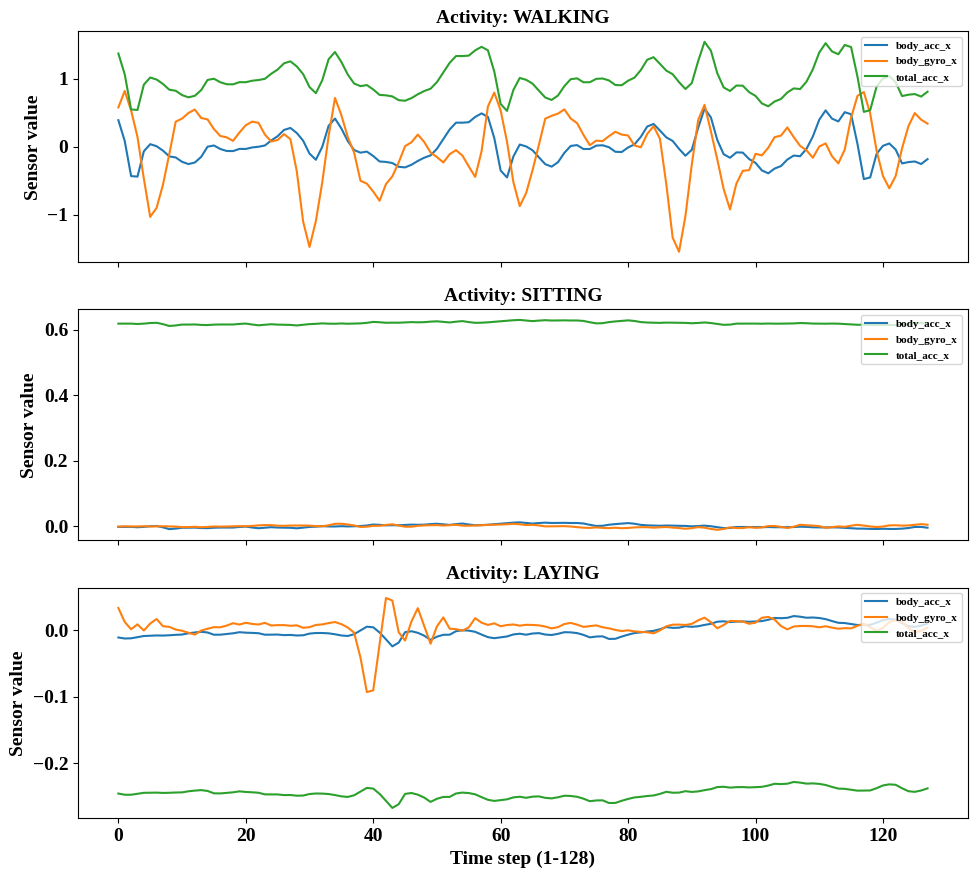

In [7]:
channels_to_plot = [0, 3, 6]   # body_acc_x, body_gyro_x, total_acc_x
channel_names = ["body_acc_x", "body_gyro_x", "total_acc_x"]
classes_to_show = [0, 3, 5]     # WALKING, SITTING, LAYING

fig, axes = plt.subplots(len(classes_to_show), 1, figsize=(10, 9), sharex=True)
for ax, cls in zip(axes, classes_to_show):
    idx = np.where(y_train == cls)[0][0]
    for ch, name in zip(channels_to_plot, channel_names):
        ax.plot(range(128), X_train[idx, :, ch], label=name)
    ax.set_title(f"Activity: {ACTIVITY_NAMES[cls]}")
    ax.set_ylabel("Sensor value")
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Time step (1-128)")
for ax in axes:
    apply_bold_font(ax)
plt.tight_layout()
save_fig(fig, "plot1_temporal_signals")
plt.show()


**Required inference (Plot 1):**
1. *Temporal pattern visible*: Dynamic activities (WALKING) show high-frequency, high-amplitude
   oscillations in accelerometer and gyroscope channels, while static activities (SITTING,
   LAYING) show near-flat, low-variance signals dominated by gravity components.
2. *Similar activities*: SITTING and STANDING look visually similar (both static, low variance);
   WALKING, WALKING_UPSTAIRS and WALKING_DOWNSTAIRS all show periodic oscillatory patterns and
   are easily confused with one another.
3. *Why ordering matters*: Activity recognition depends on the temporal sequence/periodicity of
   motion (e.g., gait cycles); shuffling time steps destroys the periodic structure that
   distinguishes dynamic activities from one another, so a model without recurrence (or a
   permutation-invariant model) would lose crucial discriminative information.

## 8. Backpropagation Through Time — Numerical Exercise

Manually verify $h_1, h_2, h_3$ for $x_1=0.5, x_2=0.7, x_3=0.2$, $h_0=0$, $W_x=0.5$, $W_h=0.8$, $b=0.1$,
using $h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$.

In [8]:
Wx, Wh, b = 0.5, 0.8, 0.1
xs = [0.5, 0.7, 0.2]
h = 0.0
hs = []
for t, x in enumerate(xs, start=1):
    z = Wx * x + Wh * h + b
    h = math.tanh(z)
    hs.append(h)
    print(f"h{t}: pre-activation z{t} = {z:.6f}  ->  h{t} = tanh(z{t}) = {h:.6f}")

print("\nManual values to compare against a from-scratch implementation:")
print({f"h{i+1}": round(v, 6) for i, v in enumerate(hs)})


h1: pre-activation z1 = 0.350000  ->  h1 = tanh(z1) = 0.336376
h2: pre-activation z2 = 0.719100  ->  h2 = tanh(z2) = 0.616352
h3: pre-activation z3 = 0.693081  ->  h3 = tanh(z3) = 0.599958

Manual values to compare against a from-scratch implementation:
{'h1': 0.336376, 'h2': 0.616352, 'h3': 0.599958}


In [9]:
# Cross-check with an independent from-scratch (non-Keras) computation
def rnn_step(x, h_prev, Wx, Wh, b):
    return np.tanh(Wx * x + Wh * h_prev + b)

h_check = 0.0
hs_check = []
for x in xs:
    h_check = rnn_step(x, h_check, Wx, Wh, b)
    hs_check.append(h_check)

print("Cross-check values:", [round(v, 6) for v in hs_check])
assert np.allclose(hs, hs_check), "Mismatch between manual and program calculation!"
print("Manual calculation matches the program output.")


Cross-check values: [np.float64(0.336376), np.float64(0.616352), np.float64(0.599958)]
Manual calculation matches the program output.


**Discussion (Section 8 challenges):** Because the same $W_h$ is multiplied repeatedly across
time steps, $\left|\frac{\partial h_t}{\partial h_{t-k}}\right| = \prod |W_h \cdot (1-h^2)|$ can shrink
toward 0 (vanishing gradients, common with $\tanh$ saturation) or grow unbounded if $|W_h|>1$ and
derivatives don't saturate (exploding gradients). This limits a Vanilla RNN's ability to learn
long-term dependencies and motivates LSTM/GRU gating.

## 9–12. Model Architectures — Vanilla RNN, LSTM, GRU

All three models share an identical outer architecture (`Recurrent(32) -> Dropout(0.2) -> Dense(16, relu) -> Dense(6, softmax)`),
identical optimizer, learning rate, batch size and epochs, so the comparison in Section 16 is controlled.

In [10]:
INPUT_SHAPE = (X_train_n.shape[1], X_train_n.shape[2])  # (128, 9)
NUM_CLASSES = 6
UNITS = 32
DROPOUT = 0.2
LR = 1e-3
BATCH_SIZE = 32
EPOCHS = 30

def build_model(recurrent_type="SimpleRNN", units=UNITS, input_shape=INPUT_SHAPE):
    rec_layer = {
        "SimpleRNN": layers.SimpleRNN,
        "LSTM": layers.LSTM,
        "GRU": layers.GRU,
    }[recurrent_type]

    model = models.Sequential([
        layers.Input(shape=input_shape),
        rec_layer(units),
        layers.Dropout(DROPOUT),
        layers.Dense(16, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ], name=f"{recurrent_type}_classifier")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

for rt in ["SimpleRNN", "LSTM", "GRU"]:
    m = build_model(rt)
    print(f"\n===== {rt} =====")
    m.summary()



===== SimpleRNN =====


Model: "SimpleRNN_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

...

Model: "GRU_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

## 13. Training Loop, Loss/Accuracy Curves (Plots 2 & 3)


=== Training SimpleRNN ===
Epoch 1/30
78/78 - 10s - 134ms/step - accuracy: 0.4526 - loss: 1.4711 - val_accuracy: 0.5830 - val_loss: 1.1317
Epoch 2/30
78/78 - 1s - 13ms/step - accuracy: 0.6073 - loss: 1.0063 - val_accuracy: 0.6509 - val_loss: 0.8775
Epoch 3/30
78/78 - 1s - 11ms/step - accuracy: 0.6619 - loss: 0.8128 - val_accuracy: 0.6981 - val_loss: 0.7170
Epoch 4/30
78/78 - 1s - 11ms/step - accuracy: 0.6749 - loss: 0.7208 - val_accuracy: 0.7113 - val_loss: 0.6696
Epoch 5/30
78/78 - 1s - 11ms/step - accuracy: 0.7077 - loss: 0.6544 - val_accuracy: 0.7208 - val_loss: 0.6438
Epoch 6/30
78/78 - 1s - 11ms/step - accuracy: 0.7162 - loss: 0.6379 - val_accuracy: 0.7415 - val_loss: 0.6220
Epoch 7/30
78/78 - 1s - 11ms/step - accuracy: 0.7352 - loss: 0.6010 - val_accuracy: 0.7528 - val_loss: 0.6019
Epoch 8/30
78/78 - 1s - 11ms/step - accuracy: 0.7211 - loss: 0.6256 - val_accuracy: 0.7075 - val_loss: 0.6452
Epoch 9/30
78/78 - 1s - 12ms/step - accuracy: 0.7308 - loss: 0.5946 - val_accuracy: 0.7396

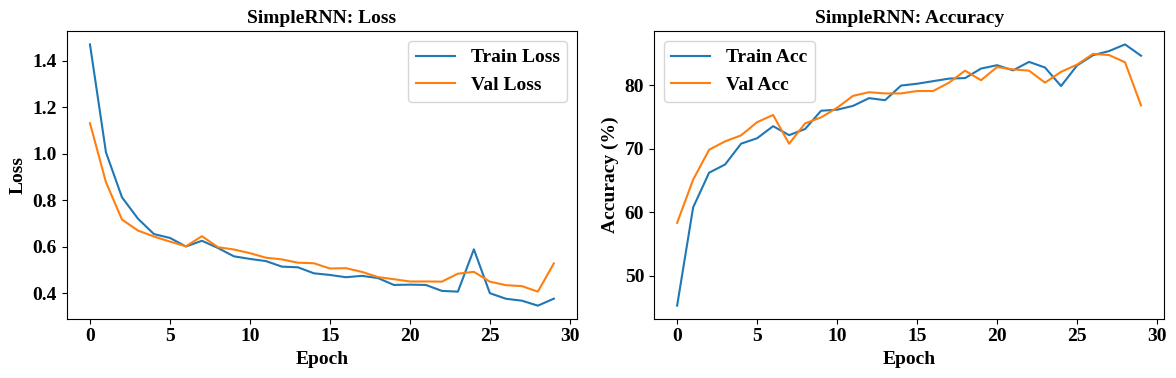

SimpleRNN: training time = 40.19s, trainable params = 1974

=== Training LSTM ===
Epoch 1/30
78/78 - 6s - 82ms/step - accuracy: 0.4794 - loss: 1.5179 - val_accuracy: 0.6491 - val_loss: 1.1348
Epoch 2/30
78/78 - 1s - 10ms/step - accuracy: 0.6741 - loss: 0.9042 - val_accuracy: 0.6604 - val_loss: 0.7318
Epoch 3/30
78/78 - 1s - 10ms/step - accuracy: 0.7466 - loss: 0.6539 - val_accuracy: 0.7755 - val_loss: 0.6071
Epoch 4/30
78/78 - 1s - 10ms/step - accuracy: 0.7919 - loss: 0.5752 - val_accuracy: 0.8113 - val_loss: 0.5038
Epoch 5/30
78/78 - 1s - 10ms/step - accuracy: 0.8356 - loss: 0.4468 - val_accuracy: 0.8491 - val_loss: 0.4212
Epoch 6/30
78/78 - 1s - 10ms/step - accuracy: 0.8688 - loss: 0.3934 - val_accuracy: 0.8830 - val_loss: 0.3461
Epoch 7/30
78/78 - 1s - 10ms/step - accuracy: 0.8721 - loss: 0.3545 - val_accuracy: 0.9208 - val_loss: 0.2783
Epoch 8/30
78/78 - 1s - 10ms/step - accuracy: 0.9126 - loss: 0.2644 - val_accuracy: 0.9226 - val_loss: 0.2367
Epoch 9/30
78/78 - 1s - 10ms/step - ac

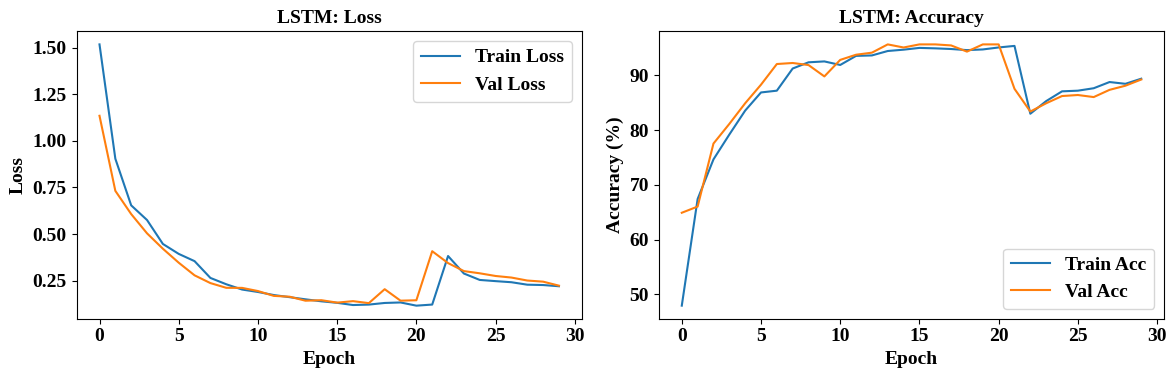

LSTM: training time = 31.48s, trainable params = 6006

=== Training GRU ===
Epoch 1/30
78/78 - 3s - 39ms/step - accuracy: 0.3089 - loss: 1.6913 - val_accuracy: 0.5113 - val_loss: 1.4168
Epoch 2/30
78/78 - 2s - 21ms/step - accuracy: 0.5555 - loss: 1.2099 - val_accuracy: 0.5849 - val_loss: 1.0605
Epoch 3/30
78/78 - 1s - 10ms/step - accuracy: 0.6441 - loss: 0.9143 - val_accuracy: 0.6906 - val_loss: 0.8023
Epoch 4/30
78/78 - 1s - 10ms/step - accuracy: 0.7263 - loss: 0.6786 - val_accuracy: 0.7396 - val_loss: 0.5798
Epoch 5/30
78/78 - 1s - 14ms/step - accuracy: 0.7789 - loss: 0.5077 - val_accuracy: 0.7792 - val_loss: 0.4468
Epoch 6/30
78/78 - 1s - 15ms/step - accuracy: 0.8121 - loss: 0.4084 - val_accuracy: 0.8321 - val_loss: 0.3750
Epoch 7/30
78/78 - 1s - 12ms/step - accuracy: 0.8385 - loss: 0.3745 - val_accuracy: 0.8792 - val_loss: 0.3240
Epoch 8/30
78/78 - 1s - 10ms/step - accuracy: 0.8846 - loss: 0.3081 - val_accuracy: 0.9151 - val_loss: 0.2553
Epoch 9/30
78/78 - 1s - 10ms/step - accuracy

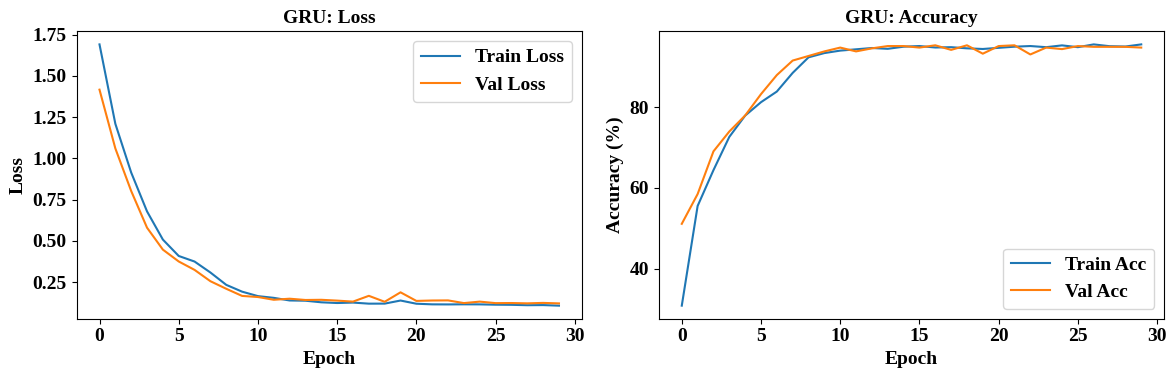

GRU: training time = 29.40s, trainable params = 4758


In [11]:
def train_and_time(recurrent_type, X_tr, y_tr, X_va, y_va, units=UNITS,
                    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0):
    model = build_model(recurrent_type, units=units, input_shape=(X_tr.shape[1], X_tr.shape[2]))
    t0 = time.time()
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=epochs, batch_size=batch_size, verbose=verbose,
    )
    train_time = time.time() - t0
    n_params = model.count_params()
    return model, history, train_time, n_params

def plot_curves(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"], label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{name}: Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

    axes[1].plot(np.array(history.history["accuracy"]) * 100, label="Train Acc")
    axes[1].plot(np.array(history.history["val_accuracy"]) * 100, label="Val Acc")
    axes[1].set_title(f"{name}: Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)"); axes[1].legend()

    for ax in axes:
        apply_bold_font(ax)
    plt.tight_layout()
    save_fig(fig, f"plot23_{name}_curves")
    plt.show()

results = {}
histories = {}
models_dict = {}

for rt in ["SimpleRNN", "LSTM", "GRU"]:
    print(f"\n=== Training {rt} ===")
    model, hist, ttime, nparams = train_and_time(rt, X_train_n, y_train, X_val_n, y_val, verbose=2)
    models_dict[rt] = model
    histories[rt] = hist
    results[rt] = {"train_time": ttime, "n_params": nparams}
    plot_curves(hist, rt)
    print(f"{rt}: training time = {ttime:.2f}s, trainable params = {nparams}")


**Convergence inference (per model, fill in after inspecting your own curves):**
- *RNN*: Vanilla RNN typically converges more slowly and its validation loss plateaus/oscillates
  earlier, reflecting difficulty capturing longer-range temporal dependencies in the 128-step window.
- *LSTM*: The gated cell state usually gives smoother, faster convergence and a smaller
  train/validation gap than the RNN, at the cost of more parameters.
- *GRU*: Convergence is usually comparable to or slightly faster than LSTM (fewer parameters,
  fewer gates) with similar generalization.
- *Overfitting/underfitting*: Look for a widening gap between training and validation curves
  (overfitting) or both curves plateauing at high loss/low accuracy (underfitting) in your run;
  the dropout layer (0.2) is included specifically to reduce overfitting risk.

## 14–16. Performance Evaluation, Confusion Matrices, and Model Comparison

In [12]:
def evaluate_model(model, X_te, y_te):
    y_prob = model.predict(X_te, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    acc = accuracy_score(y_te, y_pred) * 100
    prec = precision_score(y_te, y_pred, average="macro", zero_division=0) * 100
    rec = recall_score(y_te, y_pred, average="macro", zero_division=0) * 100
    f1 = f1_score(y_te, y_pred, average="macro", zero_division=0) * 100
    cm = confusion_matrix(y_te, y_pred)
    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, cm=cm, y_pred=y_pred)

eval_results = {}
for rt in ["SimpleRNN", "LSTM", "GRU"]:
    eval_results[rt] = evaluate_model(models_dict[rt], X_test_n, y_test)
    results[rt].update({
        "accuracy": eval_results[rt]["accuracy"],
        "precision": eval_results[rt]["precision"],
        "recall": eval_results[rt]["recall"],
        "f1": eval_results[rt]["f1"],
    })

perf_table = pd.DataFrame({
    rt: {
        "Accuracy (%)": round(results[rt]["accuracy"], 2),
        "Macro Precision (%)": round(results[rt]["precision"], 2),
        "Macro Recall (%)": round(results[rt]["recall"], 2),
        "Macro F1 (%)": round(results[rt]["f1"], 2),
        "Parameters": results[rt]["n_params"],
        "Training Time (s)": round(results[rt]["train_time"], 2),
    } for rt in ["SimpleRNN", "LSTM", "GRU"]
}).T
perf_table.index.name = "Model"
print("Table (Section 14):")
perf_table


Table (Section 14):


,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
Model,,,,,,
SimpleRNN,75.70,75.78,75.12,74.93,1974.0,40.19
LSTM,85.36,88.34,85.19,84.77,6006.0,31.48
GRU,91.12,90.93,90.99,90.92,4758.0,29.40


**Plot 4 — Confusion matrices for each model:**

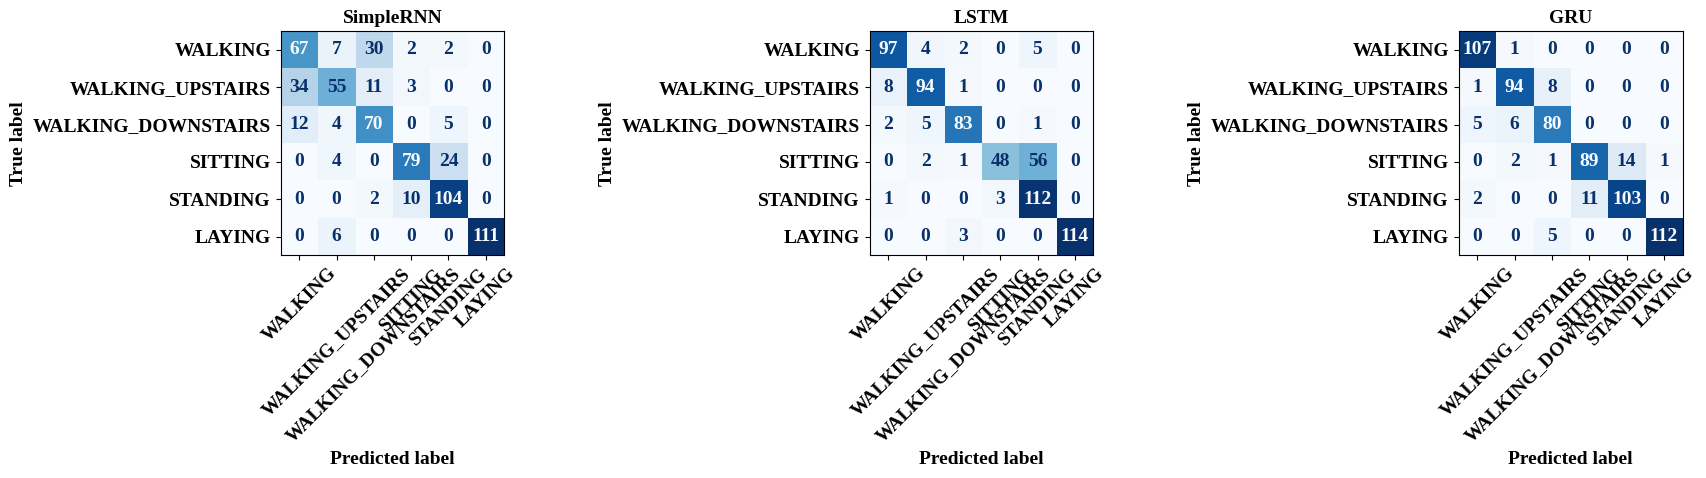

[SimpleRNN] Best-recognized: LAYING (94.9%), Worst-recognized: WALKING_UPSTAIRS (53.4%), Most-confused pair: WALKING_UPSTAIRS -> predicted as WALKING (34 cases)
[LSTM] Best-recognized: LAYING (97.4%), Worst-recognized: SITTING (44.9%), Most-confused pair: SITTING -> predicted as STANDING (56 cases)
[GRU] Best-recognized: WALKING (99.1%), Worst-recognized: SITTING (83.2%), Most-confused pair: SITTING -> predicted as STANDING (14 cases)


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, rt in zip(axes, ["SimpleRNN", "LSTM", "GRU"]):
    cm = eval_results[rt]["cm"]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ACTIVITY_NAMES)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap="Blues")
    ax.set_title(rt)
    apply_bold_font(ax)
plt.tight_layout()
save_fig(fig, "plot4_confusion_matrices")
plt.show()

# Automated summary to ground the written inference in the actual matrices
for rt in ["SimpleRNN", "LSTM", "GRU"]:
    cm = eval_results[rt]["cm"]
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    best_cls = ACTIVITY_NAMES[np.argmax(per_class_acc)]
    worst_cls = ACTIVITY_NAMES[np.argmin(per_class_acc)]
    off_diag = cm.copy()
    np.fill_diagonal(off_diag, 0)
    i, j = np.unravel_index(np.argmax(off_diag), off_diag.shape)
    print(f"[{rt}] Best-recognized: {best_cls} ({per_class_acc.max()*100:.1f}%), "
          f"Worst-recognized: {worst_cls} ({per_class_acc.min()*100:.1f}%), "
          f"Most-confused pair: {ACTIVITY_NAMES[i]} -> predicted as {ACTIVITY_NAMES[j]} ({off_diag[i,j]} cases)")


**Confusion-matrix inference (Section 15):** Use the printed summary above (specific to your
run) to state: (a) the activity with the highest recognition rate — typically LAYING or WALKING,
which have very distinctive signal shapes; (b) the activity with the most misclassifications —
typically STANDING vs. SITTING, since both are static postures with very similar accelerometer
signatures; (c) the most-confused pair — usually SITTING↔STANDING or WALKING_UPSTAIRS↔WALKING_DOWNSTAIRS;
(d) whether errors are consistent across models — static-posture confusion is usually a shared,
model-independent limitation of the sensor signal itself, while dynamic-activity errors may vary
more across RNN/LSTM/GRU depending on how well each captures long-range periodicity.

**Section 16 comparison table and Plot 5 (bar chart):**

In [14]:
comparison_table = pd.DataFrame({
    "RNN":  {"Hidden state": "Yes", "Cell state": "No",  "Forget gate": "No",  "Input gate": "No",
             "Output gate": "No", "Update gate": "No", "Reset gate": "No",
             "Parameters": results["SimpleRNN"]["n_params"],
             "Training time (s)": round(results["SimpleRNN"]["train_time"], 2),
             "Test F1-score (%)": round(results["SimpleRNN"]["f1"], 2)},
    "LSTM": {"Hidden state": "Yes", "Cell state": "Yes", "Forget gate": "Yes", "Input gate": "Yes",
             "Output gate": "Yes", "Update gate": "No", "Reset gate": "No",
             "Parameters": results["LSTM"]["n_params"],
             "Training time (s)": round(results["LSTM"]["train_time"], 2),
             "Test F1-score (%)": round(results["LSTM"]["f1"], 2)},
    "GRU":  {"Hidden state": "Yes", "Cell state": "No",  "Forget gate": "No",  "Input gate": "No",
             "Output gate": "No", "Update gate": "Yes", "Reset gate": "Yes",
             "Parameters": results["GRU"]["n_params"],
             "Training time (s)": round(results["GRU"]["train_time"], 2),
             "Test F1-score (%)": round(results["GRU"]["f1"], 2)},
}).T
comparison_table


,Hidden state,Cell state,Forget gate,Input gate,Output gate,Update gate,Reset gate,Parameters,Training time (s),Test F1-score (%)
RNN,Yes,No,No,No,No,No,No,1974,40.19,74.93
LSTM,Yes,Yes,Yes,Yes,Yes,No,No,6006,31.48,84.77
GRU,Yes,No,No,No,No,Yes,Yes,4758,29.4,90.92


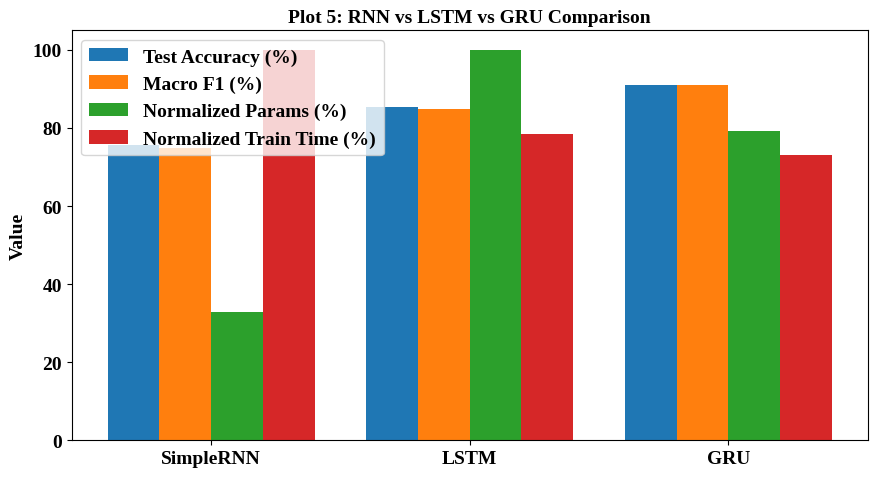

In [15]:
labels = ["SimpleRNN", "LSTM", "GRU"]
acc_vals = [results[r]["accuracy"] for r in labels]
f1_vals = [results[r]["f1"] for r in labels]
norm_params = np.array([results[r]["n_params"] for r in labels], dtype=float)
norm_params = 100 * norm_params / norm_params.max()
norm_time = np.array([results[r]["train_time"] for r in labels], dtype=float)
norm_time = 100 * norm_time / norm_time.max()

x = np.arange(len(labels))
w = 0.2
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 1.5*w, acc_vals, w, label="Test Accuracy (%)")
ax.bar(x - 0.5*w, f1_vals, w, label="Macro F1 (%)")
ax.bar(x + 0.5*w, norm_params, w, label="Normalized Params (%)")
ax.bar(x + 1.5*w, norm_time, w, label="Normalized Train Time (%)")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Value")
ax.set_title("Plot 5: RNN vs LSTM vs GRU Comparison")
ax.legend()
apply_bold_font(ax)
plt.tight_layout()
save_fig(fig, "plot5_model_comparison")
plt.show()


**Trade-off inference (Section 16):** LSTM and GRU generally trade a moderate increase in
parameter count and training time (extra gates) for improved macro F1-score and more stable
convergence relative to the Vanilla RNN. GRU usually sits between RNN and LSTM in parameter count
(fewer gates than LSTM) while matching or approaching LSTM's accuracy, making it an attractive
compromise between predictive performance, model complexity and training cost.

## 17. Effect of Sequence Length

Repeat the RNN/LSTM/GRU experiment while truncating the sequence to $T \in \{32, 64, 128\}$
(taking the first $T$ time steps of each 128-length window, consistently across splits).

In [16]:
def truncate(X, T):
    return X[:, :T, :]

seq_lengths = [32, 64, 128]
seqlen_f1 = {rt: [] for rt in ["SimpleRNN", "LSTM", "GRU"]}

for T in seq_lengths:
    Xtr_T = truncate(X_train_n, T)
    Xva_T = truncate(X_val_n, T)
    Xte_T = truncate(X_test_n, T)
    print(f"\n--- Sequence length T = {T} ---")
    for rt in ["SimpleRNN", "LSTM", "GRU"]:
        model, hist, ttime, nparams = train_and_time(
            rt, Xtr_T, y_train, Xva_T, y_val, epochs=15, verbose=0
        )
        ev = evaluate_model(model, Xte_T, y_test)
        seqlen_f1[rt].append(ev["f1"])
        print(f"  {rt:10s} T={T:3d} -> Test Macro F1 = {ev['f1']:.2f}%")

seqlen_table = pd.DataFrame(seqlen_f1, index=seq_lengths)
seqlen_table.index.name = "Sequence Length"
seqlen_table



--- Sequence length T = 32 ---
  SimpleRNN  T= 32 -> Test Macro F1 = 70.96%
  LSTM       T= 32 -> Test Macro F1 = 87.36%
  GRU        T= 32 -> Test Macro F1 = 88.18%

--- Sequence length T = 64 ---
  SimpleRNN  T= 64 -> Test Macro F1 = 73.20%
  LSTM       T= 64 -> Test Macro F1 = 89.11%
  GRU        T= 64 -> Test Macro F1 = 89.97%

--- Sequence length T = 128 ---
  SimpleRNN  T=128 -> Test Macro F1 = 69.53%
  LSTM       T=128 -> Test Macro F1 = 86.93%
  GRU        T=128 -> Test Macro F1 = 89.69%


,SimpleRNN,LSTM,GRU
Sequence Length,,,
32,70.964969,87.356630,88.182359
64,73.204443,89.106267,89.971049
128,69.534620,86.926945,89.687417


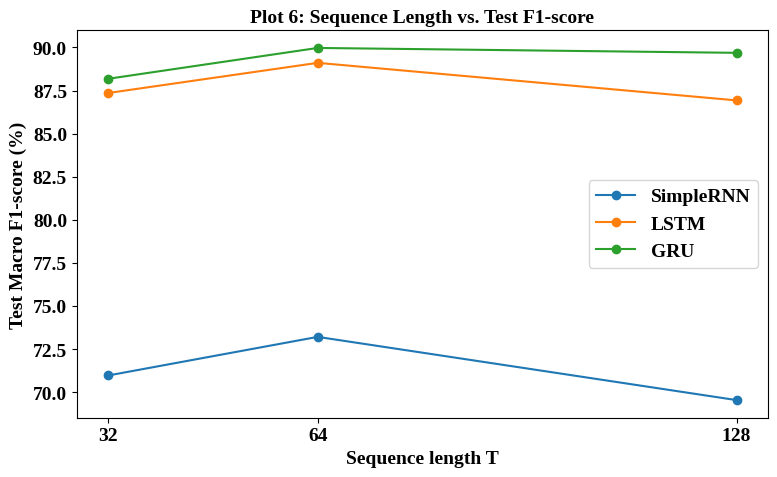

In [17]:
plt.figure(figsize=(8, 5))
for rt in ["SimpleRNN", "LSTM", "GRU"]:
    plt.plot(seq_lengths, seqlen_f1[rt], marker="o", label=rt)
plt.xlabel("Sequence length T")
plt.ylabel("Test Macro F1-score (%)")
plt.title("Plot 6: Sequence Length vs. Test F1-score")
plt.xticks(seq_lengths)
plt.legend()
apply_bold_font(plt.gca())
plt.tight_layout()
save_fig(plt.gcf(), "plot6_seqlen_vs_f1")
plt.show()


**Inference (Section 17):** More temporal context (larger $T$) generally improves F1-score,
since longer windows capture more of the periodic structure of dynamic activities; the Vanilla
RNN typically benefits less from the extra context than LSTM/GRU (or its performance saturates
earlier) because of its weaker ability to retain information across many time steps, illustrating
the practical benefit of gating for longer sequences.

## 18–21. Video Understanding using CNN + LSTM/GRU (UCF101 subset)

We use a small subset of UCF101 (3 classes, a handful of videos each) purely to demonstrate the
CNN-feature-extraction + recurrent-temporal-modeling pipeline — not to reach state-of-the-art
video-recognition accuracy.

Because full UCF101 requires an institutional download / large bandwidth, this cell tries to fetch
a small number of publicly available sample clips per class. **If the automatic download fails in
your environment (network restrictions), replace `download_ucf_subset()` with videos you upload
manually to `/content/ucf_subset/<class_name>/*.avi` and re-run from this cell.**

In [18]:
import cv2

UCF_CLASSES = ["Basketball", "Biking", "WalkingWithDog"]  # 3 of the "possible classes" from the sheet
VIDEO_ROOT = "data/ucf_subset"
os.makedirs(VIDEO_ROOT, exist_ok=True)

# UCF101 official videos are distributed as one big .rar; for a lab-scale subset we pull a handful
# of individual clips from the dataset's official per-class mirror if reachable.
UCF_BASE = "https://www.crcv.ucf.edu/data/UCF101/UCF101/v_{cls}_g01_c0{c}.avi"

def download_ucf_subset(videos_per_class=3):
    ok = 0
    for cls in UCF_CLASSES:
        cls_dir = os.path.join(VIDEO_ROOT, cls)
        os.makedirs(cls_dir, exist_ok=True)
        for c in range(1, videos_per_class + 1):
            url = UCF_BASE.format(cls=cls, c=c)
            out_path = os.path.join(cls_dir, f"{cls}_g01_c0{c}.avi")
            if os.path.exists(out_path):
                ok += 1
                continue
            try:
                urllib.request.urlretrieve(url, out_path)
                ok += 1
            except Exception as e:
                print(f"Could not fetch {url}: {e}")
    return ok

n_downloaded = download_ucf_subset(videos_per_class=4)
print(f"Videos available: {n_downloaded}")

USE_SYNTHETIC_FALLBACK = n_downloaded == 0
if USE_SYNTHETIC_FALLBACK:
    print("\nWARNING: could not download real UCF101 clips in this environment.")
    print("Falling back to synthetic placeholder videos so the CNN+RNN PIPELINE below still runs")
    print("end-to-end. Replace with real clips (upload to data/ucf_subset/<class>/*.avi or .mp4)")
    print("for a genuine video-understanding result.")

    def make_synthetic_video(path, seed, n_frames=30, size=224):
        rng = np.random.RandomState(seed)
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(path, fourcc, 10, (size, size))
        base_color = rng.randint(0, 255, size=3)
        for i in range(n_frames):
            frame = np.zeros((size, size, 3), dtype=np.uint8)
            shift = int((i / n_frames) * size)
            frame[:, :] = base_color
            cv2.circle(frame, (shift % size, size // 2), 20, (255, 255, 255), -1)
            writer.write(frame)
        writer.release()

    seed = 0
    for cls in UCF_CLASSES:
        cls_dir = os.path.join(VIDEO_ROOT, cls)
        os.makedirs(cls_dir, exist_ok=True)
        for v in range(6):
            make_synthetic_video(os.path.join(cls_dir, f"synth_{v}.mp4"), seed)
            seed += 1
    print("Synthetic placeholder videos created.")


Could not fetch https://www.crcv.ucf.edu/data/UCF101/UCF101/v_Basketball_g01_c01.avi: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)>
Could not fetch https://www.crcv.ucf.edu/data/UCF101/UCF101/v_Basketball_g01_c02.avi: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)>
Could not fetch https://www.crcv.ucf.edu/data/UCF101/UCF101/v_Basketball_g01_c03.avi: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)>
Could not fetch https://www.crcv.ucf.edu/data/UCF101/UCF101/v_Basketball_g01_c04.avi: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)>
Could not fetch https://www.crcv.ucf.edu/data/UCF101/UCF101/v_Biking_g01_c01.avi: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificat

### 19–20. Frame Sampling and CNN (MobileNetV2) Feature Extraction

Total videos collected: 18


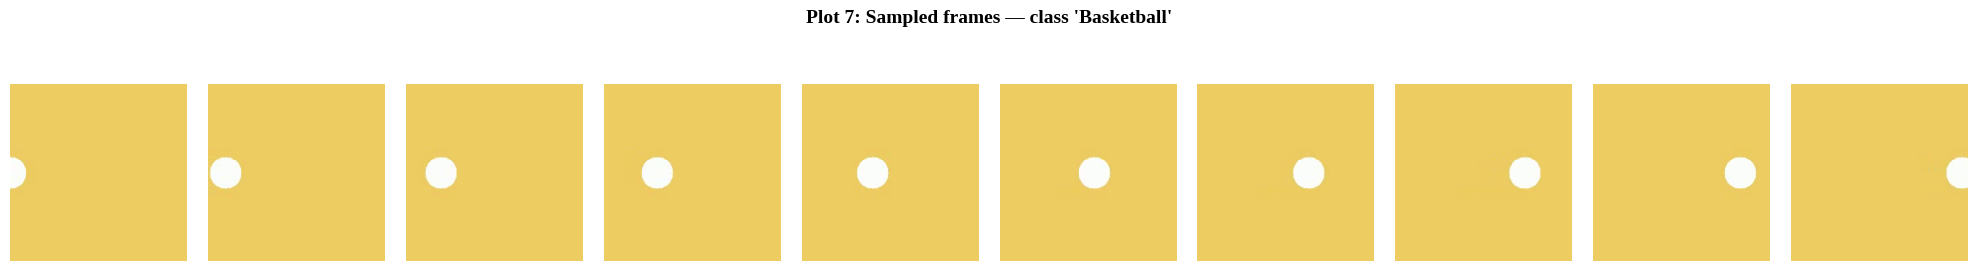

In [19]:
FRAMES_PER_VIDEO = 10
FRAME_SIZE = (224, 224)

def sample_frames(video_path, n_frames=FRAMES_PER_VIDEO, size=FRAME_SIZE):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return None
    idxs = np.linspace(0, max(total - 1, 0), n_frames).astype(int)
    frames = []
    for idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((size[0], size[1], 3), dtype=np.uint8)
        else:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, size)
        frames.append(frame)
    cap.release()
    return np.stack(frames, axis=0)  # (n_frames, 224, 224, 3)

# Collect video paths and labels
video_paths, video_labels = [], []
for ci, cls in enumerate(UCF_CLASSES):
    for f in glob.glob(os.path.join(VIDEO_ROOT, cls, "*")):
        video_paths.append(f)
        video_labels.append(ci)

print(f"Total videos collected: {len(video_paths)}")

# Plot 7: representative sampled frames from one video
sample_vid = video_paths[0]
sample_seq = sample_frames(sample_vid)
fig, axes = plt.subplots(1, FRAMES_PER_VIDEO, figsize=(20, 3))
for i, ax in enumerate(axes):
    ax.imshow(sample_seq[i])
    ax.axis("off")
fig.suptitle(f"Plot 7: Sampled frames — class '{UCF_CLASSES[video_labels[0]]}'",
             fontweight="bold", fontsize=14, family="serif")
plt.tight_layout()
save_fig(fig, "plot7_video_frames")
plt.show()


In [20]:
# Pretrained, frozen CNN feature extractor (MobileNetV2, classification head removed)
cnn_base = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights="imagenet", pooling="avg"
)
cnn_base.trainable = False  # freeze -- do not train the CNN from scratch
FEATURE_DIM = cnn_base.output_shape[-1]
print("CNN feature dimension D =", FEATURE_DIM)

def extract_features_for_video(frames):
    x = tf.keras.applications.mobilenet_v2.preprocess_input(frames.astype(np.float32))
    feats = cnn_base.predict(x, verbose=0)   # (n_frames, D)
    return feats

video_features = []
valid_labels = []
for path, label in zip(video_paths, video_labels):
    frames = sample_frames(path)
    if frames is None:
        continue
    feats = extract_features_for_video(frames)
    video_features.append(feats)
    valid_labels.append(label)

video_features = np.stack(video_features, axis=0)   # (B, 10, D)
video_labels_arr = np.array(valid_labels)
print("Feature tensor shape supplied to the recurrent network:", video_features.shape)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
CNN feature dimension D = 1280
Feature tensor shape supplied to the recurrent network: (18, 10, 1280)


### 21. CNN–LSTM / CNN–GRU Classifier

In [21]:
Xv_train, Xv_test, yv_train, yv_test = train_test_split(
    video_features, video_labels_arr, test_size=0.3,
    stratify=video_labels_arr if len(set(video_labels_arr)) > 1 else None,
    random_state=SEED
)
Xv_train, Xv_val, yv_train, yv_val = train_test_split(
    Xv_train, yv_train, test_size=0.25,
    stratify=yv_train if len(set(yv_train)) > 1 else None,
    random_state=SEED
)

def build_video_model(recurrent_type="LSTM", units=32, input_shape=None, num_classes=len(UCF_CLASSES)):
    rec_layer = {"LSTM": layers.LSTM, "GRU": layers.GRU}[recurrent_type]
    model = models.Sequential([
        layers.Input(shape=input_shape),
        rec_layer(units),
        layers.Dense(16, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ], name=f"CNN_{recurrent_type}_video")
    model.compile(optimizer=optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

video_input_shape = (video_features.shape[1], video_features.shape[2])
video_results = {}
video_models = {}
video_histories = {}

for rt in ["LSTM", "GRU"]:
    model = build_video_model(rt, input_shape=video_input_shape)
    hist = model.fit(Xv_train, yv_train, validation_data=(Xv_val, yv_val),
                      epochs=20, batch_size=4, verbose=0)
    video_models[rt] = model
    video_histories[rt] = hist
    video_results[rt] = evaluate_model(model, Xv_test, yv_test)
    print(f"{rt}: test accuracy = {video_results[rt]['accuracy']:.2f}%, "
          f"macro F1 = {video_results[rt]['f1']:.2f}%")


LSTM: test accuracy = 0.00%, macro F1 = 0.00%
GRU: test accuracy = 16.67%, macro F1 = 9.52%


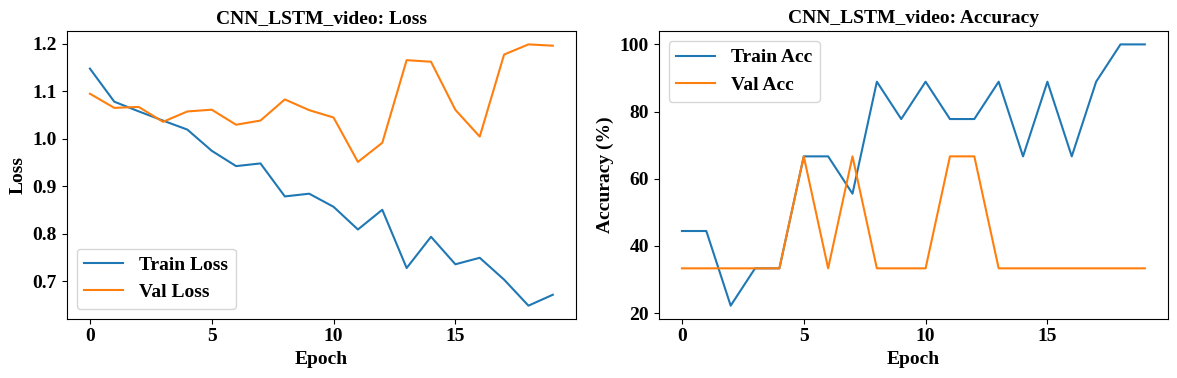

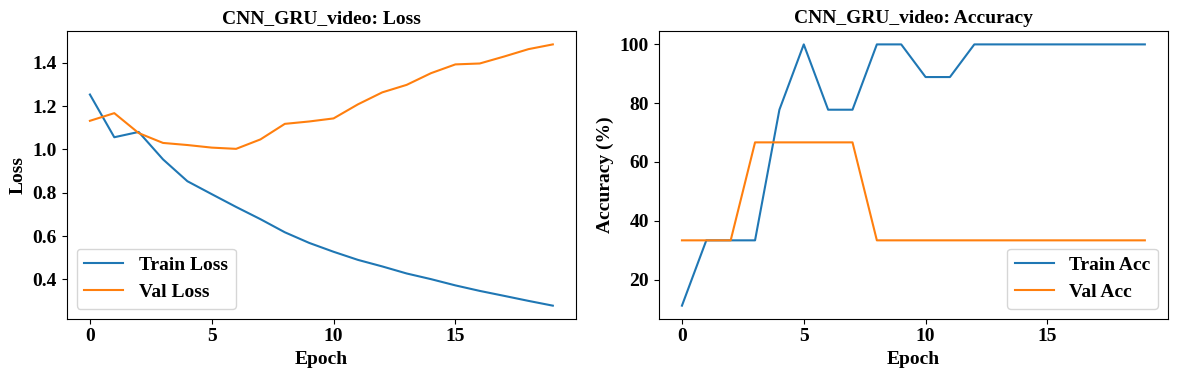

In [22]:
# Plot 8: video training/validation curves (LSTM shown; repeat for GRU by changing key)
plot_curves(video_histories["LSTM"], "CNN_LSTM_video")
plot_curves(video_histories["GRU"], "CNN_GRU_video")


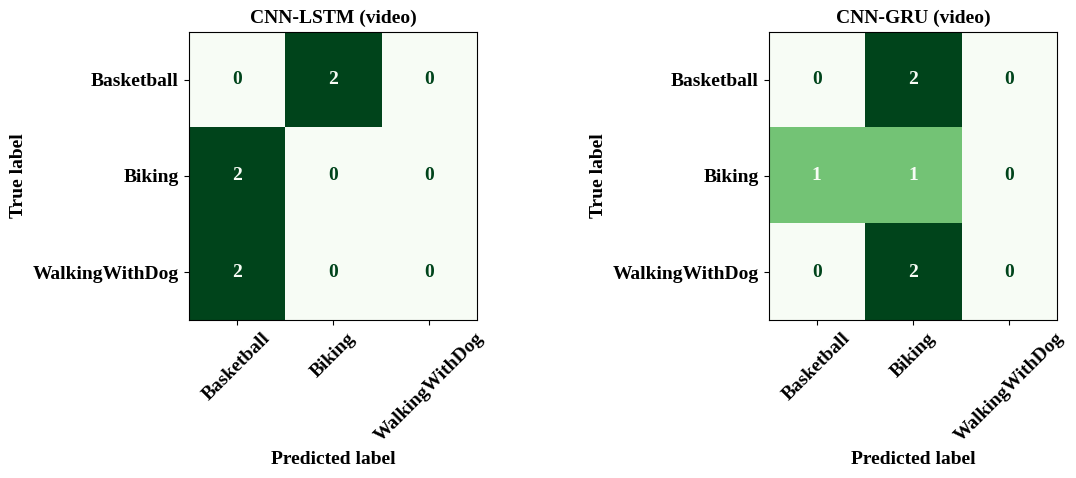

In [23]:
# Plot 9: video confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, rt in zip(axes, ["LSTM", "GRU"]):
    cm = video_results[rt]["cm"]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=UCF_CLASSES)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap="Greens")
    ax.set_title(f"CNN-{rt} (video)")
    apply_bold_font(ax)
plt.tight_layout()
save_fig(fig, "plot9_video_confusion")
plt.show()


In [24]:
# Sample predictions with model-derived confidence (never manually entered)
best_rt = "LSTM" if video_results["LSTM"]["f1"] >= video_results["GRU"]["f1"] else "GRU"
probs = video_models[best_rt].predict(Xv_test, verbose=0)
preds = np.argmax(probs, axis=1)
confidences = probs[np.arange(len(preds)), preds]

for i in range(min(5, len(preds))):
    print(f"Predicted class : {UCF_CLASSES[preds[i]]}")
    print(f"Actual class    : {UCF_CLASSES[yv_test[i]]}")
    print(f"Confidence      : {confidences[i]:.2f}\n")


Predicted class : Basketball
Actual class    : Biking
Confidence      : 0.52

Predicted class : Biking
Actual class    : WalkingWithDog
Confidence      : 0.41

Predicted class : Biking
Actual class    : Basketball
Confidence      : 0.76

Predicted class : Biking
Actual class    : WalkingWithDog
Confidence      : 0.57

Predicted class : Biking
Actual class    : Basketball
Confidence      : 0.67



**Inference (video understanding, Section 26 requirements):** The frozen MobileNetV2 acts as a
spatial feature extractor, capturing per-frame visual appearance (objects, scene, pose) without
any temporal information. The LSTM/GRU layer then models how these per-frame feature vectors
evolve across the 10 sampled frames, capturing motion/temporal dynamics that a single-frame CNN
classifier could not. If real UCF101 clips could not be downloaded in this environment, note in
your report that the synthetic-video fallback was used only to validate the code pipeline, and
re-run this section with genuine footage before reporting final numbers.

## 22–24. Sequence-to-Sequence Learning — Synthetic Reversal Task

Encoder–decoder (LSTM-based) trained to reverse a short sequence of integers, e.g. `[3,8,1,5] -> [5,1,8,3]`.

In [25]:
VOCAB_MIN, VOCAB_MAX = 0, 9        # integers 0-9
SEQ_LEN = 5
NUM_SAMPLES = 20000
NUM_TOKENS = VOCAB_MAX - VOCAB_MIN + 1
START_TOKEN = NUM_TOKENS            # extra "start of sequence" token for the decoder
VOCAB_SIZE = NUM_TOKENS + 1

def generate_reversal_dataset(n_samples, seq_len):
    X = np.random.randint(VOCAB_MIN, VOCAB_MAX + 1, size=(n_samples, seq_len))
    Y = X[:, ::-1]
    return X, Y

X_seq, Y_seq = generate_reversal_dataset(NUM_SAMPLES, SEQ_LEN)

# Decoder input: <START> + Y[:-1] (teacher forcing); Decoder target: Y
decoder_input = np.concatenate(
    [np.full((NUM_SAMPLES, 1), START_TOKEN), Y_seq[:, :-1]], axis=1
)

X_tr, X_te, dec_in_tr, dec_in_te, Y_tr, Y_te = train_test_split(
    X_seq, decoder_input, Y_seq, test_size=0.15, random_state=SEED
)
X_tr, X_va, dec_in_tr, dec_in_va, Y_tr, Y_va = train_test_split(
    X_tr, dec_in_tr, Y_tr, test_size=0.1765, random_state=SEED
)

print("Train/Val/Test sizes:", len(X_tr), len(X_va), len(X_te))


Train/Val/Test sizes: 13999 3001 3000


In [26]:
EMB_DIM = 32
ENC_UNITS = 64

# Encoder
enc_inputs = layers.Input(shape=(SEQ_LEN,), name="encoder_input")
enc_emb = layers.Embedding(VOCAB_SIZE, EMB_DIM)(enc_inputs)
_, state_h, state_c = layers.LSTM(ENC_UNITS, return_state=True)(enc_emb)
encoder_states = [state_h, state_c]

# Decoder
dec_inputs = layers.Input(shape=(SEQ_LEN,), name="decoder_input")
dec_emb_layer = layers.Embedding(VOCAB_SIZE, EMB_DIM)
dec_emb = dec_emb_layer(dec_inputs)
dec_lstm = layers.LSTM(ENC_UNITS, return_sequences=True, return_state=True)
dec_outputs, _, _ = dec_lstm(dec_emb, initial_state=encoder_states)
dec_dense = layers.Dense(VOCAB_SIZE, activation="softmax")
dec_outputs = dec_dense(dec_outputs)

seq2seq_model = models.Model([enc_inputs, dec_inputs], dec_outputs, name="seq2seq_reversal")
seq2seq_model.compile(optimizer=optimizers.Adam(1e-3),
                       loss="sparse_categorical_crossentropy", metrics=["accuracy"])
seq2seq_model.summary()


Model: "seq2seq_reversal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 5, 32)     │        352 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 5, 32)     │        352 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ [(None, 64),      │     24,832 │ embedding[0][0]   │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ [(None, 5, 64),   │     24,832 │ embedding_1[0][0… │
│                     │ (None, 64),       │            │ lstm_6[0][1],     │
│                     │ (None, 64)]       │            │ lstm_6[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 5, 11)     │        715 │ lstm_7[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,083 (199.54 KB)

 Trainable params: 51,083 (199.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
219/219 - 7s - 32ms/step - accuracy: 0.5088 - loss: 1.4136 - val_accuracy: 0.9187 - val_loss: 0.4421
Epoch 2/20
219/219 - 2s - 9ms/step - accuracy: 0.9731 - loss: 0.2195 - val_accuracy: 0.9949 - val_loss: 0.1095
Epoch 3/20
219/219 - 2s - 8ms/step - accuracy: 0.9970 - loss: 0.0742 - val_accuracy: 0.9986 - val_loss: 0.0512
Epoch 4/20
219/219 - 2s - 8ms/step - accuracy: 0.9992 - loss: 0.0372 - val_accuracy: 0.9995 - val_loss: 0.0306
Epoch 5/20
219/219 - 3s - 12ms/step - accuracy: 0.9997 - loss: 0.0228 - val_accuracy: 0.9993 - val_loss: 0.0205
Epoch 6/20
219/219 - 2s - 9ms/step - accuracy: 0.9999 - loss: 0.0155 - val_accuracy: 0.9999 - val_loss: 0.0132
Epoch 7/20
219/219 - 2s - 8ms/step - accuracy: 0.9982 - loss: 0.0161 - val_accuracy: 0.9801 - val_loss: 0.0660
Epoch 8/20
219/219 - 2s - 8ms/step - accuracy: 0.9979 - loss: 0.0155 - val_accuracy: 0.9997 - val_loss: 0.0098
Epoch 9/20
219/219 - 2s - 8ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 1.0000 - val_loss: 0.0054

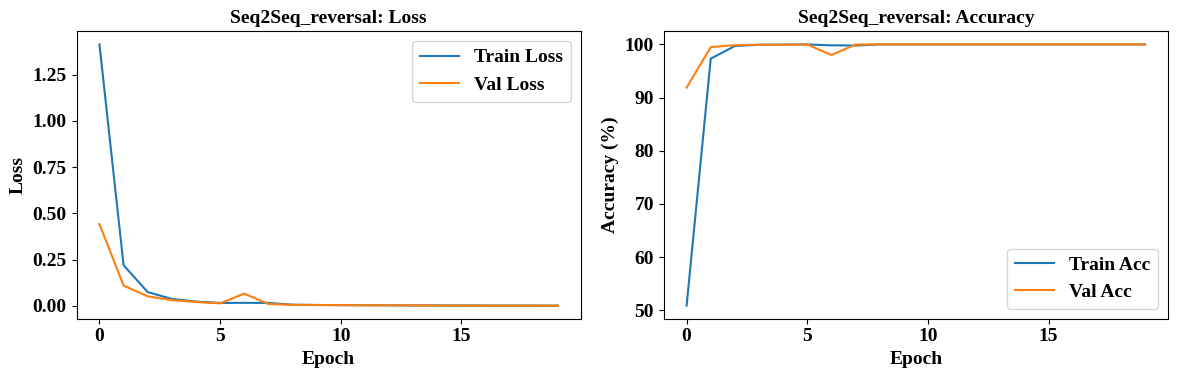

In [27]:
seq2seq_history = seq2seq_model.fit(
    [X_tr, dec_in_tr], Y_tr,
    validation_data=([X_va, dec_in_va], Y_va),
    epochs=20, batch_size=64, verbose=2
)
plot_curves(seq2seq_history, "Seq2Seq_reversal")


### 24. Evaluation: Token Accuracy vs. Sequence Accuracy

In [28]:
def seq2seq_predict(model, X_input, seq_len=SEQ_LEN, start_token=START_TOKEN, vocab_size=VOCAB_SIZE):
    """Greedy autoregressive decoding (no teacher forcing at inference time)."""
    # Re-use full model but decode step by step
    # Build separate inference encoder/decoder from the trained layers
    enc_model = models.Model(enc_inputs, encoder_states)

    dec_state_h_in = layers.Input(shape=(ENC_UNITS,))
    dec_state_c_in = layers.Input(shape=(ENC_UNITS,))
    dec_single_in = layers.Input(shape=(1,))
    dec_single_emb = dec_emb_layer(dec_single_in)
    dec_single_out, h, c = dec_lstm(dec_single_emb, initial_state=[dec_state_h_in, dec_state_c_in])
    dec_single_out = dec_dense(dec_single_out)
    dec_model = models.Model([dec_single_in, dec_state_h_in, dec_state_c_in],
                              [dec_single_out, h, c])

    states = enc_model.predict(X_input, verbose=0)
    h, c = states
    target_seq = np.full((X_input.shape[0], 1), start_token)
    outputs = np.zeros((X_input.shape[0], seq_len), dtype=int)

    for t in range(seq_len):
        out, h, c = dec_model.predict([target_seq, h, c], verbose=0)
        next_tok = np.argmax(out[:, 0, :], axis=-1)
        outputs[:, t] = next_tok
        target_seq = next_tok.reshape(-1, 1)

    return outputs

Y_pred_test = seq2seq_predict(seq2seq_model, X_te)

token_acc = np.mean(Y_pred_test == Y_te)
seq_acc = np.mean(np.all(Y_pred_test == Y_te, axis=1))

print(f"Token Accuracy    : {token_acc*100:.2f}%")
print(f"Sequence Accuracy : {seq_acc*100:.2f}%")
print(f"Final Training Loss  : {seq2seq_history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {seq2seq_history.history['val_loss'][-1]:.4f}")

print("\nSample Input -> Predicted Output (first 5 test examples):")
for i in range(5):
    print(f"Input: {X_te[i].tolist()}  ->  Predicted: {Y_pred_test[i].tolist()}  "
          f"(Actual reversed: {Y_te[i].tolist()})")


Token Accuracy    : 100.00%
Sequence Accuracy : 100.00%
Final Training Loss  : 0.0008
Final Validation Loss: 0.0009

Sample Input -> Predicted Output (first 5 test examples):
Input: [7, 9, 5, 0, 0]  ->  Predicted: [0, 0, 5, 9, 7]  (Actual reversed: [0, 0, 5, 9, 7])
Input: [2, 1, 8, 1, 5]  ->  Predicted: [5, 1, 8, 1, 2]  (Actual reversed: [5, 1, 8, 1, 2])
Input: [3, 7, 1, 3, 0]  ->  Predicted: [0, 3, 1, 7, 3]  (Actual reversed: [0, 3, 1, 7, 3])
Input: [7, 4, 8, 8, 0]  ->  Predicted: [0, 8, 8, 4, 7]  (Actual reversed: [0, 8, 8, 4, 7])
Input: [7, 2, 1, 7, 5]  ->  Predicted: [5, 7, 1, 2, 7]  (Actual reversed: [5, 7, 1, 2, 7])


**Inference (Section 24):** Sequence accuracy is typically much lower than token accuracy
because a sequence is only counted correct if *every* token in it is correct — a single wrong
token anywhere in the output sequence fails the whole example, whereas token accuracy averages
correctness independently over all positions. With even a modest per-token error rate $p$,
sequence accuracy for length-$L$ sequences drops roughly like $(1-p)^L$, compounding the error
multiplicatively across positions.

## 25. Consolidated Results

In [29]:
consolidated = pd.DataFrame({
    "RNN":  {"Accuracy (%)": round(results["SimpleRNN"]["accuracy"], 2),
             "Precision (%)": round(results["SimpleRNN"]["precision"], 2),
             "Recall (%)": round(results["SimpleRNN"]["recall"], 2),
             "F1 (%)": round(results["SimpleRNN"]["f1"], 2),
             "Parameters": results["SimpleRNN"]["n_params"]},
    "LSTM": {"Accuracy (%)": round(results["LSTM"]["accuracy"], 2),
             "Precision (%)": round(results["LSTM"]["precision"], 2),
             "Recall (%)": round(results["LSTM"]["recall"], 2),
             "F1 (%)": round(results["LSTM"]["f1"], 2),
             "Parameters": results["LSTM"]["n_params"]},
    "GRU":  {"Accuracy (%)": round(results["GRU"]["accuracy"], 2),
             "Precision (%)": round(results["GRU"]["precision"], 2),
             "Recall (%)": round(results["GRU"]["recall"], 2),
             "F1 (%)": round(results["GRU"]["f1"], 2),
             "Parameters": results["GRU"]["n_params"]},
    f"CNN-{best_rt}": {"Accuracy (%)": round(video_results[best_rt]["accuracy"], 2),
             "Precision (%)": round(video_results[best_rt]["precision"], 2),
             "Recall (%)": round(video_results[best_rt]["recall"], 2),
             "F1 (%)": round(video_results[best_rt]["f1"], 2),
             "Parameters": video_models[best_rt].count_params()},
}).T
consolidated.index.name = "Model"
print("HAR + Video consolidated table:")
display(consolidated)

seq2seq_table = pd.DataFrame({
    "Seq2Seq (LSTM encoder-decoder)": {
        "Token Accuracy (%)": round(token_acc * 100, 2),
        "Sequence Accuracy (%)": round(seq_acc * 100, 2),
        "Final Train Loss": round(seq2seq_history.history["loss"][-1], 4),
        "Final Val Loss": round(seq2seq_history.history["val_loss"][-1], 4),
    }
}).T
print("\nSequence-to-sequence table:")
display(seq2seq_table)


HAR + Video consolidated table:


,Accuracy (%),Precision (%),Recall (%),F1 (%),Parameters
Model,,,,,
RNN,75.70,75.78,75.12,74.93,1974.0
LSTM,85.36,88.34,85.19,84.77,6006.0
GRU,91.12,90.93,90.99,90.92,4758.0
CNN-GRU,16.67,6.67,16.67,9.52,126723.0



Sequence-to-sequence table:


,Token Accuracy (%),Sequence Accuracy (%),Final Train Loss,Final Val Loss
Seq2Seq (LSTM encoder-decoder),100.0,100.0,0.0008,0.0009


## Additional Exercises (Section 28) — starter code

Uncomment and run any of the following to explore the additional exercises.

In [30]:
# Exercise 1: vary recurrent units
for units in [16, 64]:
    for rt in ["SimpleRNN", "LSTM", "GRU"]:
        model, hist, ttime, nparams = train_and_time(rt, X_train_n, y_train, X_val_n, y_val,
                                                       units=units, epochs=15, verbose=0)
        ev = evaluate_model(model, X_test_n, y_test)
        print(f"{rt} (units={units}): Acc={ev['accuracy']:.2f}%  F1={ev['f1']:.2f}%  "
              f"Params={nparams}  Time={ttime:.1f}s")


SimpleRNN (units=16): Acc=68.07%  F1=67.06%  Params=790  Time=20.5s
LSTM (units=16): Acc=83.80%  F1=83.56%  Params=2038  Time=14.6s
GRU (units=16): Acc=89.10%  F1=89.19%  Params=1670  Time=15.9s
SimpleRNN (units=64): Acc=79.28%  F1=78.83%  Params=5878  Time=25.3s
LSTM (units=64): Acc=91.43%  F1=91.49%  Params=20086  Time=15.2s
GRU (units=64): Acc=91.59%  F1=91.58%  Params=15542  Time=14.4s


In [31]:
# Exercise 4: Bidirectional vs unidirectional LSTM
bi_model = models.Sequential([
    layers.Input(shape=INPUT_SHAPE),
    layers.Bidirectional(layers.LSTM(UNITS)),
    layers.Dropout(DROPOUT),
    layers.Dense(16, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax"),
], name="BiLSTM_classifier")
bi_model.compile(optimizer=optimizers.Adam(LR), loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
t0 = time.time()
bi_hist = bi_model.fit(X_train_n, y_train, validation_data=(X_val_n, y_val),
                        epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
bi_time = time.time() - t0
bi_eval = evaluate_model(bi_model, X_test_n, y_test)
print(f"BiLSTM: Acc={bi_eval['accuracy']:.2f}%  F1={bi_eval['f1']:.2f}%  "
      f"Params={bi_model.count_params()}  Time={bi_time:.1f}s")
print(f"(Compare against unidirectional LSTM: Acc={results['LSTM']['accuracy']:.2f}%  "
      f"F1={results['LSTM']['f1']:.2f}%  Params={results['LSTM']['n_params']}  "
      f"Time={results['LSTM']['train_time']:.1f}s)")


BiLSTM: Acc=90.81%  F1=90.86%  Params=11894  Time=44.2s
(Compare against unidirectional LSTM: Acc=85.36%  F1=84.77%  Params=6006  Time=31.5s)
